# Prototype 3: IBRProxy Co-Simulation with PSS/E

## Overview

This notebook demonstrates **FMU-style co-simulation** where an IBR (Inverter-Based Resource) proxy model receives grid measurements (voltage, frequency) and returns power setpoints (P, Q).

### Co-Simulation Loop

```
┌─────────────────────────────────────────────────────────────────┐
│                     Time Step Loop                              │
├─────────────────────────────────────────────────────────────────┤
│  1. PSS/E provides: V_pu (voltage), f_Hz (frequency)           │
│                          ↓                                      │
│  2. IBRProxy computes: P_mw, Q_mvar = f(V, f, t, WEC_profile)  │
│                          ↓                                      │
│  3. PSS/E receives: load_chng_5(-P, -Q)  (negative = inject)   │
│                          ↓                                      │
│  4. PSS/E advances: run(t + dt)                                 │
└─────────────────────────────────────────────────────────────────┘
```

### IBRProxy Features

- **Base setpoint**: Interpolated from WEC time-series power profile
- **Voltage droop**: Q adjustment for voltage support (capacitive/inductive)
- **Frequency droop**: P adjustment for frequency support
- **Limits**: P ≥ 0 (WEC can't absorb), |Q| ≤ Q_max

### Future: FMU Integration

Replace `ibr.compute_output()` with:
```python
fmu.setReal([v_ref, f_ref], [voltage_pu, freq_hz])
fmu.doStep(current_time, step_size)
P, Q = fmu.getReal([p_ref, q_ref])
```

In [10]:
# =============================================================================
# Part 1: PSS/E Initialization
# =============================================================================
"""
Prototype 3: IBRProxy Integration with PSS/E Dynamic Simulation
Restart kernel before running if you encounter PSS/E state issues.
"""

import os
import sys

# PSS/E Xplore 35.5 path setup
PSSE_PATH = r"C:\Program Files\PTI\PSSE35\35.5"
sys.path.insert(0, rf"{PSSE_PATH}\PSSPY37")
sys.path.insert(0, rf"{PSSE_PATH}\PSSBIN")
os.environ["PATH"] = rf"{PSSE_PATH}\PSSPY37;{PSSE_PATH}\PSSBIN;" + os.environ["PATH"]

import psspy
import dyntools

print(f"PSS/E initialized")
print(f"  psspy: {psspy.__file__}")
print(f"  dyntools: {dyntools.__file__}")

PSS/E initialized
  psspy: C:\Program Files\PTI\PSSE35\35.5\PSSPY37\psspy.pyc
  dyntools: C:\Program Files\PTI\PSSE35\35.5\PSSPY37\dyntools.pyc


In [11]:
# =============================================================================
# Part 2: Imports and Configuration
# =============================================================================

import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Initialize PSS/E (50 buses for Xplore version)
psspy.psseinit(50)

# -----------------------------------------------------------------------------
# File Paths
# -----------------------------------------------------------------------------
case_dir = Path.cwd()
ieee14_dir = (case_dir / '..' / 'cpds_cosim' / 'machine_1' / 'Transmission' / 'ieee_14').resolve()

RAW_FILE = ieee14_dir / 'ieee14.raw'   # Power flow data
DYR_FILE = ieee14_dir / 'ieee14.dyr'   # Dynamic model data
OUT_FILE = case_dir / 'prototype3_ibr.out'  # Simulation output

# -----------------------------------------------------------------------------
# WEC/IBR Configuration
# -----------------------------------------------------------------------------
WEC_BUS = 100           # New bus for WEC farm
CONNECTING_BUS = 11     # Grid connection point (138 kV)
WEC_LOAD_ID = 'W1'      # Load ID for WEC proxy
NUM_WEC_DEVICES = 100   # Number of WEC devices in farm

# Simulation parameters
SIM_STEP = 0.1          # PSS/E timestep (seconds)
WEC_START = 100.0       # Start time in WEC data (seconds)
WEC_END = 130.0         # End time in WEC data (seconds)

print("Configuration:")
print(f"  RAW: {RAW_FILE}")
print(f"  DYR: {DYR_FILE}")
print(f"  OUT: {OUT_FILE}")
print(f"  WEC Bus: {WEC_BUS} → Grid Bus: {CONNECTING_BUS}")
print(f"  Devices: {NUM_WEC_DEVICES}")

Configuration:
  RAW: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.raw
  DYR: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.dyr
  OUT: c:\Users\alexb\research\WEC-GRID\nrel_test\prototype3_ibr.out
  WEC Bus: 100 → Grid Bus: 11
  Devices: 100


In [12]:
# =============================================================================
# Part 3: Load Power Flow Case and Add WEC Bus
# =============================================================================

# Load RAW file
ierr = psspy.read(0, str(RAW_FILE))
if ierr != 0:
    raise RuntimeError(f"Failed to load RAW file: ierr={ierr}")
print(f"✓ RAW file loaded")

# Get base voltage from connecting bus
ierr, base_kv = psspy.busdat(CONNECTING_BUS, 'BASE')
print(f"  Connecting bus {CONNECTING_BUS}: {base_kv:.0f} kV")

# -----------------------------------------------------------------------------
# Add WEC Bus
# -----------------------------------------------------------------------------
ierr = psspy.bus_data_4(
    ibus=WEC_BUS,
    inode=0,
    intgar1=1,              # Bus type: PQ
    realar1=base_kv,        # Base voltage
    name=f"WEC_{WEC_BUS}",
)
print(f"  Added WEC bus {WEC_BUS}: ierr={ierr}")

# -----------------------------------------------------------------------------
# Add Transmission Line (WEC → Grid)
# -----------------------------------------------------------------------------
realar = [0.0] * 12
realar[0] = 0.01   # R (pu)
realar[1] = 0.05   # X (pu)
realar[2] = 0.02   # B (pu)

ierr = psspy.branch_data_3(WEC_BUS, CONNECTING_BUS, '1', 1, realar)
print(f"  Added line {WEC_BUS}→{CONNECTING_BUS}: ierr={ierr}")

# -----------------------------------------------------------------------------
# Add Load Proxy (initially zero)
# -----------------------------------------------------------------------------
intgar = [1, 1, 1, 1, 1, 0, 0]
realar_load = [0.0] * 8

ierr = psspy.load_data_6(WEC_BUS, WEC_LOAD_ID, intgar, realar_load)
print(f"  Added load proxy '{WEC_LOAD_ID}': ierr={ierr}")

# -----------------------------------------------------------------------------
# Solve Power Flow
# -----------------------------------------------------------------------------
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
print(f"  Power flow: ierr={ierr}")

ierr, v_pu = psspy.busdat(WEC_BUS, 'PU')
print(f"\n✓ Topology complete: WEC Bus {WEC_BUS} = {v_pu:.4f} pu")

✓ RAW file loaded
  Connecting bus 11: 138 kV
  Added WEC bus 100: ierr=0
  Added line 100→11: ierr=-1
  Added load proxy 'W1': ierr=0
  Power flow: ierr=0

✓ Topology complete: WEC Bus 100 = 1.0001 pu


In [13]:
# =============================================================================
# Part 4: Dynamic Conversion
# =============================================================================
# Convert to dynamics AFTER all topology changes.
# CONL is a 3-step API!

print("Dynamic Conversion:")

# CONL Step 1: Initialize
ierr, remaining = psspy.conl(-1, 1, 1, [0, 0], [0.0, 0.0, 0.0, 0.0])
print(f"  conl(1): ierr={ierr}")

# CONL Step 2: Convert loads
ierr, remaining = psspy.conl(-1, 1, 2, [0, 0], [100.0, 0.0, 100.0, 0.0])
print(f"  conl(2): ierr={ierr}")

# CONL Step 3: Cleanup
ierr, remaining = psspy.conl(-1, 1, 3, [0, 0], [0.0, 0.0, 0.0, 0.0])
print(f"  conl(3): ierr={ierr}")

# Remaining conversion steps
ierr = psspy.cong(0)
print(f"  cong: ierr={ierr}")

ierr = psspy.ordr(0)
print(f"  ordr: ierr={ierr}")

ierr = psspy.fact()
print(f"  fact: ierr={ierr}")

ierr = psspy.tysl(0)
print(f"  tysl: ierr={ierr}")

# Load DYR
ierr = psspy.dyre_new([1, 1, 1, 1], str(DYR_FILE), '', '', '')
print(f"  dyre_new: ierr={ierr}")

if ierr == 0:
    print("\n✓ Dynamic initialization complete")
else:
    print(f"\n⚠ dyre_new warning: ierr={ierr}")

Dynamic Conversion:
  conl(1): ierr=0
  conl(2): ierr=0
  conl(3): ierr=0
  cong: ierr=0
  ordr: ierr=0
  fact: ierr=0
  tysl: ierr=0
  dyre_new: ierr=0

✓ Dynamic initialization complete


In [14]:
# =============================================================================
# Part 5: Load WEC Data and Create IBRProxy
# =============================================================================

database_path = (case_dir / '..' / 'examples' / 'WECGrid.db').resolve()
print(f"Loading WEC data from: {database_path.name}")

# Query WEC power data
conn = sqlite3.connect(database_path)
query = '''
    SELECT time_sec, device_index, p_w, q_var
    FROM wec_power_results
    WHERE wec_sim_id = 1
    ORDER BY time_sec, device_index
'''
wec_power_df = pd.read_sql_query(query, conn)
conn.close()

# Aggregate to farm level and scale
farm_power = wec_power_df.groupby('time_sec').agg({'p_w': 'sum', 'q_var': 'sum'}).reset_index()
farm_power['p_mw'] = farm_power['p_w'] / 1e6 * NUM_WEC_DEVICES
farm_power['q_mvar'] = farm_power['q_var'] / 1e6 * NUM_WEC_DEVICES

# Select time window
profile = farm_power.query('time_sec >= @WEC_START and time_sec <= @WEC_END').copy()
profile = profile.reset_index(drop=True)
profile['sim_time'] = np.arange(len(profile)) * SIM_STEP

print(f"\nWEC Farm Profile ({NUM_WEC_DEVICES} devices):")
print(f"  Power range: {profile['p_mw'].min():.2f} to {profile['p_mw'].max():.2f} MW")
print(f"  Time steps: {len(profile)} ({profile['sim_time'].max():.1f}s)")

# -----------------------------------------------------------------------------
# Create IBRProxy Instance
# -----------------------------------------------------------------------------
ibr = IBRProxy(
    power_profile=profile,
    p_column='p_mw',
    q_column='q_mvar',
    time_column='sim_time',
    p_rated=profile['p_mw'].max(),           # Use peak WEC power
    q_max=profile['p_mw'].max() * 0.5,       # 50% reactive capability
    v_droop=0.05,                            # 5% voltage droop
    f_droop=0.04                             # 4% frequency droop
)

print(f"\n✓ Created: {ibr}")

# Test IBR at nominal conditions
print("\nIBRProxy Test Cases:")
test = ibr.compute_output(voltage_pu=1.0, freq_hz=60.0, time_sec=5.0)
print(f"  Nominal (V=1.0, f=60Hz): P={test['P_mw']:.3f} MW, Q={test['Q_mvar']:.3f} Mvar")

test = ibr.compute_output(voltage_pu=0.95, freq_hz=60.0, time_sec=5.0)
print(f"  Low V   (V=0.95, f=60Hz): P={test['P_mw']:.3f} MW, Q={test['Q_mvar']:.3f} Mvar (Q droop: +{test['Q_droop']:.3f})")

test = ibr.compute_output(voltage_pu=1.0, freq_hz=59.9, time_sec=5.0)
print(f"  Low f   (V=1.0, f=59.9Hz): P={test['P_mw']:.3f} MW (P droop: +{test['P_droop']:.3f}), Q={test['Q_mvar']:.3f} Mvar")

Loading WEC data from: WECGrid.db

WEC Farm Profile (100 devices):
  Power range: 1.31 to 1.42 MW
  Time steps: 301 (30.0s)

✓ Created: IBRProxy(p_rated=1.42 MW, q_max=0.71 Mvar, v_droop=5.0%, f_droop=4.0%)

IBRProxy Test Cases:
  Nominal (V=1.0, f=60Hz): P=1.316 MW, Q=0.000 Mvar
  Low V   (V=0.95, f=60Hz): P=1.316 MW, Q=0.710 Mvar (Q droop: +0.710)
  Low f   (V=1.0, f=59.9Hz): P=4.863 MW (P droop: +3.548), Q=0.000 Mvar

WEC Farm Profile (100 devices):
  Power range: 1.31 to 1.42 MW
  Time steps: 301 (30.0s)

✓ Created: IBRProxy(p_rated=1.42 MW, q_max=0.71 Mvar, v_droop=5.0%, f_droop=4.0%)

IBRProxy Test Cases:
  Nominal (V=1.0, f=60Hz): P=1.316 MW, Q=0.000 Mvar
  Low V   (V=0.95, f=60Hz): P=1.316 MW, Q=0.710 Mvar (Q droop: +0.710)
  Low f   (V=1.0, f=59.9Hz): P=4.863 MW (P droop: +3.548), Q=0.000 Mvar


In [15]:
# =============================================================================
# Part 6: Run Co-Simulation Loop
# =============================================================================
# This is the main FMU-style integration:
#   1. PSS/E provides V, f
#   2. IBRProxy computes P, Q
#   3. PSS/E receives load update
#   4. Advance time

# Clean up old output files
for ext in (".out", ".outx"):
    f = OUT_FILE.with_suffix(ext)
    if f.exists():
        f.unlink()
        print(f"Deleted: {f.name}")

# Suppress progress output
psspy.progress_output(6, '', [0, 0])

# -----------------------------------------------------------------------------
# Configure Output Channels
# -----------------------------------------------------------------------------
# Channel types: 12=FREQ, 13=VOLT
psspy.chsb(0, 1, [-1, -1, -1, 1, 13, 0])  # VOLT all buses
psspy.chsb(0, 1, [-1, -1, -1, 1, 12, 0])  # FREQ all buses
print("✓ Output channels configured (VOLT, FREQ)")

# -----------------------------------------------------------------------------
# Start Simulation
# -----------------------------------------------------------------------------
ierr = psspy.strt_2([0, 0], str(OUT_FILE))
if ierr != 0:
    raise RuntimeError(f"strt_2 failed: ierr={ierr}")

# Initial step
psspy.run(0, 0.0, 1, 1, 0)
print(f"✓ Simulation started (output: {OUT_FILE.name})")

# Reset IBR call counter
ibr.call_count = 0

# -----------------------------------------------------------------------------
# Co-Simulation Loop
# -----------------------------------------------------------------------------
results = []
current_time = 0.0

print(f"\nRunning IBR co-simulation ({len(profile)} steps)...")
print(f"{'Step':>5} {'Time':>7} {'V_pu':>8} {'f_Hz':>8} {'P_set':>7} {'P_out':>7} {'Q_out':>7}")
print("-" * 60)

for idx, (_, row) in enumerate(profile.iterrows()):
    target_time = current_time + SIM_STEP
    
    # -------------------------------------------------------------------------
    # Step 1: Get grid state from PSS/E
    # -------------------------------------------------------------------------
    ierr, voltage_pu = psspy.busdat(WEC_BUS, 'PU')
    
    # Read frequency from output file (dyntools)
    # Note: This reads the latest value from the .out file
    try:
        chn = dyntools.CHNF(str(OUT_FILE))
        _, chanid, chandata = chn.get_data()
        
        # Find frequency channel for WEC bus or first available
        freq_hz = 60.0  # Default
        for k, v in chanid.items():
            if 'FREQ' in str(v).upper() and k != 'time':
                freq_data = chandata[k]
                if len(freq_data) > 0:
                    # PSS/E FREQ is deviation in pu: f = 60 * (1 + FREQ)
                    freq_dev = freq_data[-1]
                    if abs(freq_dev) < 1.0:  # It's pu deviation
                        freq_hz = 60.0 * (1.0 + freq_dev)
                    else:
                        freq_hz = freq_dev
                break
    except Exception as e:
        freq_hz = 60.0  # Fallback to nominal
    
    # -------------------------------------------------------------------------
    # Step 2: Call IBRProxy (this is where FMU would be called)
    # -------------------------------------------------------------------------
    ibr_output = ibr.compute_output(
        voltage_pu=voltage_pu,
        freq_hz=freq_hz,
        time_sec=target_time
    )
    
    # -------------------------------------------------------------------------
    # Step 3: Apply IBR output to PSS/E load
    # -------------------------------------------------------------------------
    # NEGATIVE load = generation (power injection into grid)
    psspy.load_chng_5(
        WEC_BUS, WEC_LOAD_ID, [],
        [-ibr_output['P_mw'], -ibr_output['Q_mvar'], 0.0, 0.0, 0.0, 0.0]
    )
    
    # -------------------------------------------------------------------------
    # Step 4: Advance PSS/E simulation
    # -------------------------------------------------------------------------
    psspy.run(0, target_time, 1, 1, 0)
    
    # Record results
    results.append({
        'sim_time': target_time,
        'voltage_pu': voltage_pu,
        'freq_hz': freq_hz,
        'P_setpoint': ibr_output['P_setpoint'],
        'P_output': ibr_output['P_mw'],
        'P_droop': ibr_output['P_droop'],
        'Q_output': ibr_output['Q_mvar'],
        'Q_droop': ibr_output['Q_droop'],
    })
    
    current_time = target_time
    
    # Progress output
    if idx % 50 == 0:
        print(f"{idx:5d} {target_time:7.1f} {voltage_pu:8.4f} {freq_hz:8.4f} "
              f"{ibr_output['P_setpoint']:7.2f} {ibr_output['P_mw']:7.2f} {ibr_output['Q_mvar']:7.3f}")

# Restore progress output
psspy.progress_output(1, '', [0, 0])

# Create results DataFrame
results_df = pd.DataFrame(results)

print("-" * 60)
print(f"\n✓ Co-simulation complete")
print(f"  IBR calls: {ibr.call_count}")
print(f"  Duration: {results_df['sim_time'].max():.1f}s")
print(f"  P range: {results_df['P_output'].min():.3f} to {results_df['P_output'].max():.3f} MW")
print(f"  Q range: {results_df['Q_output'].min():.3f} to {results_df['Q_output'].max():.3f} Mvar")

✓ Output channels configured (VOLT, FREQ)
✓ Simulation started (output: prototype3_ibr.out)

Running IBR co-simulation (301 steps)...
 Step    Time     V_pu     f_Hz   P_set   P_out   Q_out
------------------------------------------------------------
    0     0.1   1.0001  60.0000    1.32    1.32  -0.001
   50     5.1   1.0008  60.0090    1.32    1.00  -0.011
   50     5.1   1.0008  60.0090    1.32    1.00  -0.011
  100    10.1   1.0008  60.0083    1.35    1.05  -0.012
  100    10.1   1.0008  60.0083    1.35    1.05  -0.012
  150    15.1   1.0009  60.0084    1.41    1.11  -0.013
  150    15.1   1.0009  60.0084    1.41    1.11  -0.013
  200    20.1   1.0009  60.0082    1.41    1.12  -0.013
  200    20.1   1.0009  60.0082    1.41    1.12  -0.013
  250    25.1   1.0009  60.0080    1.39    1.10  -0.012
  250    25.1   1.0009  60.0080    1.39    1.10  -0.012
  300    30.1   1.0009  60.0080    1.39    1.11  -0.013
------------------------------------------------------------

✓ Co-simulation

In [16]:
# =============================================================================
# Part 7: Read Final Output File for Complete Frequency Data
# =============================================================================
# Re-read the complete output file for accurate frequency time-series

print(f"Reading complete output file: {OUT_FILE.name}")
chn = dyntools.CHNF(str(OUT_FILE))
short_title, chanid, chandata = chn.get_data()

time_out = np.array(chandata['time'])
print(f"  Time range: {time_out[0]:.2f}s to {time_out[-1]:.2f}s ({len(time_out)} points)")

# Find frequency channel
freq_channel = None
for k, v in chanid.items():
    if 'FREQ' in str(v).upper() and k != 'time':
        freq_channel = k
        print(f"  Using frequency channel {k}: {v}")
        break

# Interpolate frequency to match our simulation timesteps
if freq_channel:
    freq_raw = np.array(chandata[freq_channel])
    freq_interp = np.interp(results_df['sim_time'], time_out, freq_raw)
    
    # Convert from pu deviation to Hz
    if np.abs(freq_interp).max() < 1.0:
        results_df['freq_hz_final'] = 60.0 * (1.0 + freq_interp)
    else:
        results_df['freq_hz_final'] = freq_interp
else:
    results_df['freq_hz_final'] = 60.0

print(f"\n  Final frequency range: {results_df['freq_hz_final'].min():.4f} to {results_df['freq_hz_final'].max():.4f} Hz")

Reading complete output file: prototype3_ibr.out
  Time range: -0.02s to 30.11s (3917 points)
  Using frequency channel 16: FREQ 1 [BUS1 69.000]

  Final frequency range: 60.0033 to 60.0116 Hz


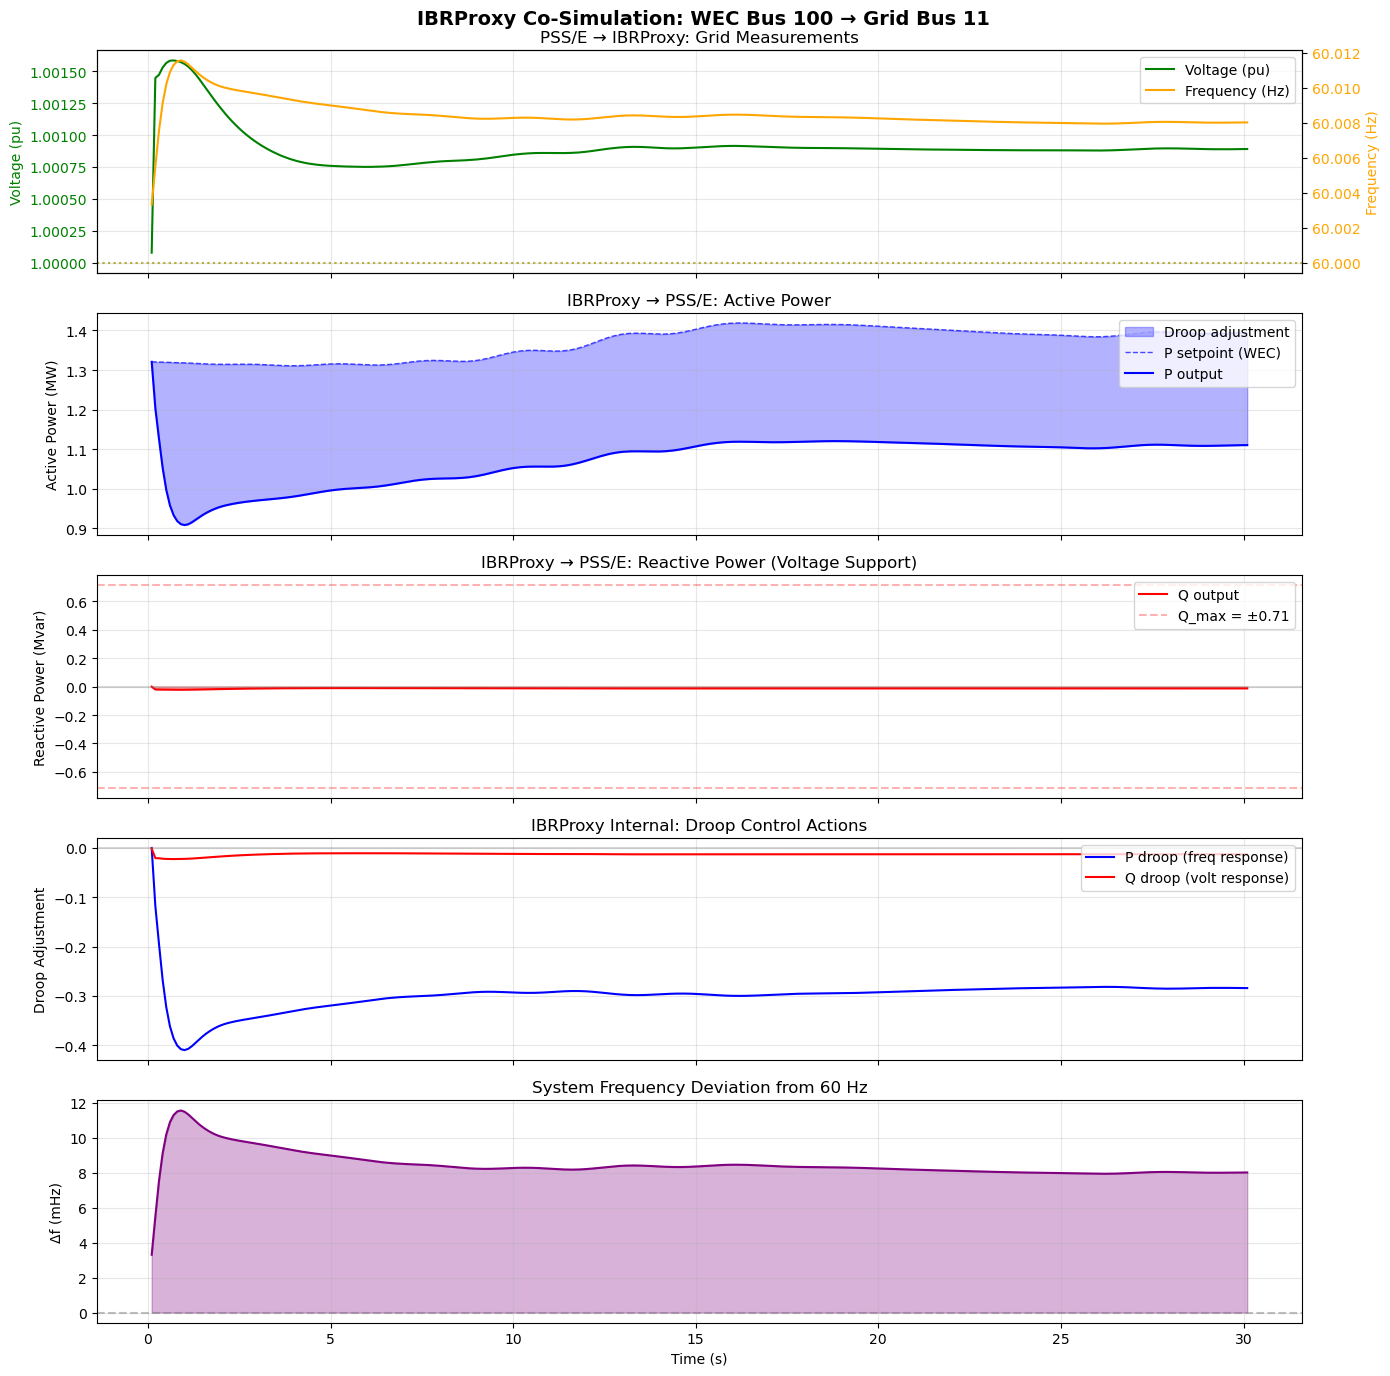


IBR CO-SIMULATION SUMMARY
  WEC Bus: 100 → Grid Bus: 11
  IBR Proxy: IBRProxy(p_rated=1.42 MW, q_max=0.71 Mvar, v_droop=5.0%, f_droop=4.0%)
  Simulation: 30.1s, 301 steps
  IBR calls: 301
----------------------------------------------------------------------
  INPUTS (PSS/E → IBR):
    Voltage:   1.0001 - 1.0016 pu
    Frequency: 60.0033 - 60.0116 Hz
----------------------------------------------------------------------
  OUTPUTS (IBR → PSS/E):
    P setpoint: 1.311 - 1.419 MW
    P output:   0.908 - 1.321 MW
    Q output:   -0.022 - -0.001 Mvar
----------------------------------------------------------------------
  DROOP RESPONSE:
    Max P droop: 0.4100 MW (freq support)
    Max Q droop: 0.0225 Mvar (volt support)


In [17]:
# =============================================================================
# Part 8: Visualize Results
# =============================================================================

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
fig.suptitle(f'IBRProxy Co-Simulation: WEC Bus {WEC_BUS} → Grid Bus {CONNECTING_BUS}', 
             fontsize=14, fontweight='bold')

# -------------------------------------------------------------------------
# Plot 1: Grid Inputs to IBR (V, f)
# -------------------------------------------------------------------------
ax1 = axes[0]
ax1_twin = ax1.twinx()

ln1 = ax1.plot(results_df['sim_time'], results_df['voltage_pu'], 'g-', lw=1.5, label='Voltage (pu)')
ax1.axhline(1.0, color='green', linestyle=':', alpha=0.5)
ax1.set_ylabel('Voltage (pu)', color='green')
ax1.tick_params(axis='y', labelcolor='green')

ln2 = ax1_twin.plot(results_df['sim_time'], results_df['freq_hz_final'], 'orange', lw=1.5, label='Frequency (Hz)')
ax1_twin.axhline(60.0, color='orange', linestyle=':', alpha=0.5)
ax1_twin.set_ylabel('Frequency (Hz)', color='orange')
ax1_twin.tick_params(axis='y', labelcolor='orange')

ax1.set_title('PSS/E → IBRProxy: Grid Measurements')
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper right')
ax1.grid(alpha=0.3)

# -------------------------------------------------------------------------
# Plot 2: Active Power (Setpoint vs Output)
# -------------------------------------------------------------------------
ax2 = axes[1]
ax2.fill_between(results_df['sim_time'], results_df['P_setpoint'], results_df['P_output'],
                 alpha=0.3, color='blue', label='Droop adjustment')
ax2.plot(results_df['sim_time'], results_df['P_setpoint'], 'b--', lw=1, alpha=0.7, label='P setpoint (WEC)')
ax2.plot(results_df['sim_time'], results_df['P_output'], 'b-', lw=1.5, label='P output')
ax2.set_ylabel('Active Power (MW)')
ax2.set_title('IBRProxy → PSS/E: Active Power')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

# -------------------------------------------------------------------------
# Plot 3: Reactive Power
# -------------------------------------------------------------------------
ax3 = axes[2]
ax3.fill_between(results_df['sim_time'], 0, results_df['Q_output'], alpha=0.3, color='red')
ax3.plot(results_df['sim_time'], results_df['Q_output'], 'r-', lw=1.5, label='Q output')
ax3.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax3.axhline(ibr.q_max, color='red', linestyle='--', alpha=0.3, label=f'Q_max = ±{ibr.q_max:.2f}')
ax3.axhline(-ibr.q_max, color='red', linestyle='--', alpha=0.3)
ax3.set_ylabel('Reactive Power (Mvar)')
ax3.set_title('IBRProxy → PSS/E: Reactive Power (Voltage Support)')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

# -------------------------------------------------------------------------
# Plot 4: Droop Responses
# -------------------------------------------------------------------------
ax4 = axes[3]
ax4.plot(results_df['sim_time'], results_df['P_droop'], 'b-', lw=1.5, label='P droop (freq response)')
ax4.plot(results_df['sim_time'], results_df['Q_droop'], 'r-', lw=1.5, label='Q droop (volt response)')
ax4.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax4.set_ylabel('Droop Adjustment')
ax4.set_title('IBRProxy Internal: Droop Control Actions')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)

# -------------------------------------------------------------------------
# Plot 5: Frequency Deviation
# -------------------------------------------------------------------------
ax5 = axes[4]
freq_dev_mhz = (results_df['freq_hz_final'] - 60.0) * 1000
ax5.fill_between(results_df['sim_time'], 0, freq_dev_mhz, alpha=0.3, color='purple')
ax5.plot(results_df['sim_time'], freq_dev_mhz, 'purple', lw=1.5)
ax5.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax5.set_ylabel('Δf (mHz)')
ax5.set_xlabel('Time (s)')
ax5.set_title('System Frequency Deviation from 60 Hz')
ax5.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Summary Statistics
# -------------------------------------------------------------------------
print("\n" + "=" * 70)
print("IBR CO-SIMULATION SUMMARY")
print("=" * 70)
print(f"  WEC Bus: {WEC_BUS} → Grid Bus: {CONNECTING_BUS}")
print(f"  IBR Proxy: {ibr}")
print(f"  Simulation: {results_df['sim_time'].max():.1f}s, {len(results_df)} steps")
print(f"  IBR calls: {ibr.call_count}")
print(f"-" * 70)
print(f"  INPUTS (PSS/E → IBR):")
print(f"    Voltage:   {results_df['voltage_pu'].min():.4f} - {results_df['voltage_pu'].max():.4f} pu")
print(f"    Frequency: {results_df['freq_hz_final'].min():.4f} - {results_df['freq_hz_final'].max():.4f} Hz")
print(f"-" * 70)
print(f"  OUTPUTS (IBR → PSS/E):")
print(f"    P setpoint: {results_df['P_setpoint'].min():.3f} - {results_df['P_setpoint'].max():.3f} MW")
print(f"    P output:   {results_df['P_output'].min():.3f} - {results_df['P_output'].max():.3f} MW")
print(f"    Q output:   {results_df['Q_output'].min():.3f} - {results_df['Q_output'].max():.3f} Mvar")
print(f"-" * 70)
print(f"  DROOP RESPONSE:")
print(f"    Max P droop: {results_df['P_droop'].abs().max():.4f} MW (freq support)")
print(f"    Max Q droop: {results_df['Q_droop'].abs().max():.4f} Mvar (volt support)")
print("=" * 70)

---

## Summary: IBRProxy Co-Simulation Pattern

### What This Demonstrates

This notebook shows the complete **FMU-style co-simulation loop**:

```python
for each timestep:
    # 1. Get grid measurements from PSS/E
    V = psspy.busdat(WEC_BUS, 'PU')
    f = dyntools read frequency from .out file
    
    # 2. Call IBRProxy (placeholder for FMU)
    P, Q = ibr.compute_output(V, f, t)
    
    # 3. Inject power into PSS/E
    psspy.load_chng_5(WEC_BUS, 'W1', [], [-P, -Q, ...])
    
    # 4. Advance PSS/E
    psspy.run(0, t + dt, ...)
```

### IBRProxy Features

| Feature | Description |
|---------|-------------|
| **Base Setpoint** | Interpolated from WEC time-series power profile |
| **Voltage Droop** | Q adjustment for voltage support (inject Q when V low) |
| **Frequency Droop** | P adjustment for frequency support (increase P when f low) |
| **Limits** | P ≥ 0 (no absorption), \|Q\| ≤ Q_max |

### To Replace with Actual FMU

```python
from fmpy import read_model_description, instantiate_fmu

# Replace IBRProxy with:
fmu = instantiate_fmu(fmu_path)
fmu.setReal([v_ref], [voltage_pu])
fmu.setReal([f_ref], [freq_hz])
fmu.doStep(current_time, step_size)
P = fmu.getReal([p_ref])[0]
Q = fmu.getReal([q_ref])[0]
```

### Key Integration Points

1. **Voltage**: Read with `psspy.busdat(bus, 'PU')` - instant value
2. **Frequency**: Read from `.out` file via `dyntools.CHNF` - requires output file
3. **Power Injection**: Use `psspy.load_chng_5()` with **negative** P/Q for generation
4. **Time Advance**: Use `psspy.run()` to step simulation forward